In [1]:
# =========================================
# Titanic Survival Analysis - EDA Project
# Using Seaborn Dataset
# =========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# Plot Styling
plt.style.use('ggplot')
sns.set_theme(style='whitegrid')

In [2]:
# =========================================
# Load Dataset (SEABORN)
# =========================================

print("Loading Titanic Dataset from Seaborn...")

df = sns.load_dataset("titanic")

print("Dataset Loaded Successfully!")

Loading Titanic Dataset from Seaborn...
Dataset Loaded Successfully!


In [3]:
# =========================================
# Create Images Folder
# =========================================

if not os.path.exists('images'):
    os.makedirs('images')

In [4]:
# =========================================
# Basic Dataset Information
# =========================================

print("\n===== DATASET SHAPE =====")
print(df.shape)

print("\n===== DATASET COLUMNS =====")
print(df.columns)

print("\n===== DATASET INFO =====")
print(df.info())

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

print("\n===== STATISTICAL SUMMARY =====")
print(df.describe(include='all'))



===== DATASET SHAPE =====
(891, 15)

===== DATASET COLUMNS =====
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

===== DATASET INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_

In [5]:
# =========================================
# Data Cleaning
# =========================================

print("\n===== DATA CLEANING =====")

df['age'] = df['age'].fillna(df['age'].median())
df['fare'] = df['fare'].fillna(df['fare'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Drop cabin (too many missing values)
df.drop(columns=['deck'], inplace=True, errors='ignore')

print("Missing Values Handled Successfully!")



===== DATA CLEANING =====
Missing Values Handled Successfully!


In [6]:
# =========================================
# Feature Engineering
# =========================================

print("\n===== FEATURE ENGINEERING =====")

df['FamilySize'] = df['sibsp'] + df['parch'] + 1

bins = [0, 12, 19, 59, 100]
labels = ['Child', 'Teen', 'Adult', 'Senior']

df['AgeGroup'] = pd.cut(df['age'], bins=bins, labels=labels)

print("Feature Engineering Completed!")



===== FEATURE ENGINEERING =====
Feature Engineering Completed!


In [7]:
# =========================================
# KPI Calculations
# =========================================

print("\n===== BUSINESS KPIs =====")

total_passengers = len(df)
total_survivors = (df['survived'] == 1).sum()
total_non_survivors = (df['survived'] == 0).sum()

survival_rate = round((total_survivors / total_passengers) * 100, 2)

print(f"Total Passengers: {total_passengers}")
print(f"Total Survivors: {total_survivors}")
print(f"Total Non-Survivors: {total_non_survivors}")
print(f"Overall Survival Rate: {survival_rate}%")


===== BUSINESS KPIs =====
Total Passengers: 891
Total Survivors: 342
Total Non-Survivors: 549
Overall Survival Rate: 38.38%


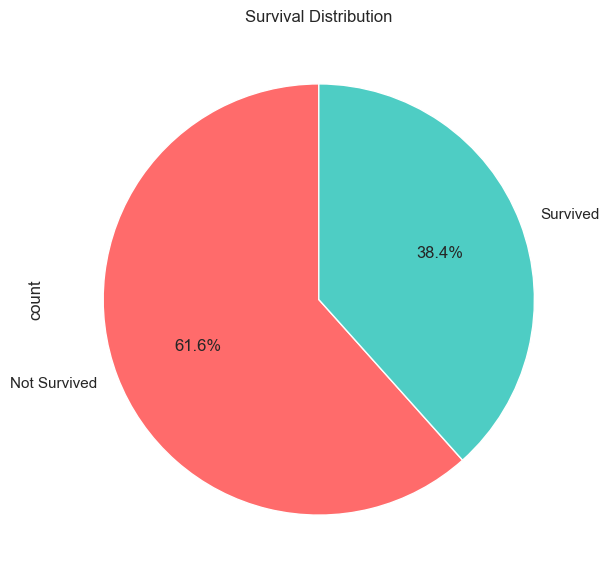

In [8]:
# =========================================
# 1. Survival Distribution
# =========================================

plt.figure(figsize=(7, 7))

labels = ['Not Survived', 'Survived']
colors = ['#ff6b6b', '#4ecdc4']

df['survived'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=labels,
    colors=colors,
    startangle=90
)

plt.title('Survival Distribution')
plt.savefig('images/survival_distribution.png', bbox_inches='tight')
plt.show()


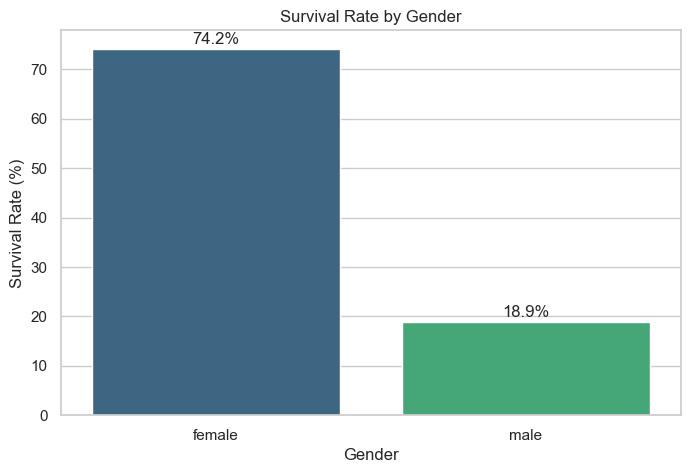

In [9]:
# =========================================
# 2. Survival by Gender
# =========================================

plt.figure(figsize=(8, 5))

gender_survival = df.groupby('sex')['survived'].mean() * 100

sns.barplot(x=gender_survival.index, y=gender_survival.values, palette='viridis')

plt.title('Survival Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Survival Rate (%)')

for i, v in enumerate(gender_survival.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.savefig('images/gender_survival.png', bbox_inches='tight')
plt.show()

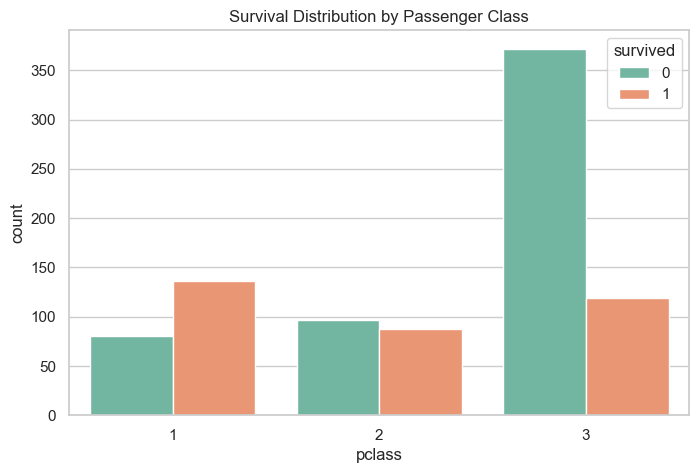

In [10]:
# =========================================
# 3. Survival by Passenger Class
# =========================================

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='pclass', hue='survived', palette='Set2')

plt.title('Survival Distribution by Passenger Class')
plt.savefig('images/class_survival.png', bbox_inches='tight')
plt.show()

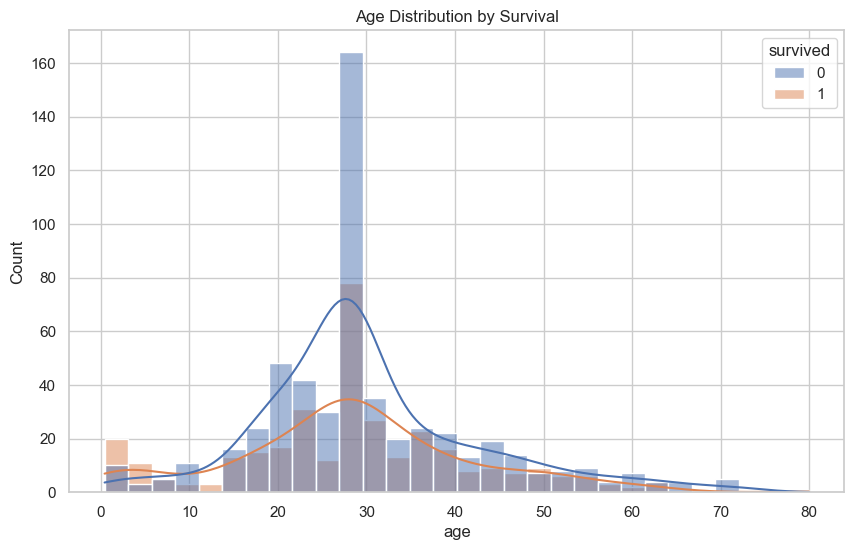

In [11]:
# =========================================
# 4. Age Distribution by Survival
# =========================================

plt.figure(figsize=(10, 6))

sns.histplot(data=df, x='age', hue='survived', bins=30, kde=True)

plt.title('Age Distribution by Survival')
plt.savefig('images/age_distribution.png', bbox_inches='tight')
plt.show()

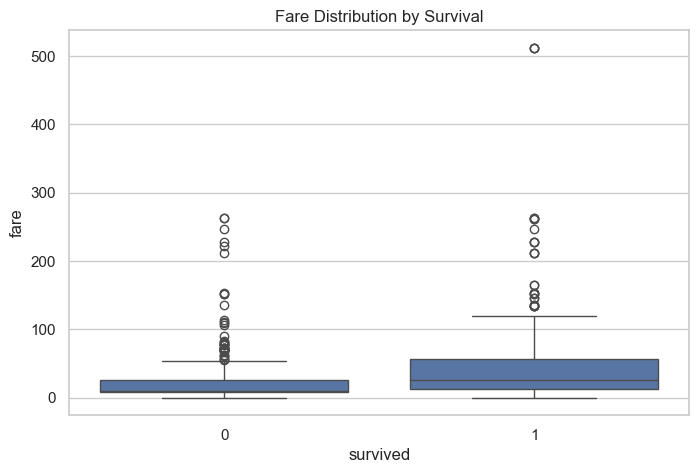

In [12]:
# =========================================
# 5. Fare vs Survival
# =========================================

plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='survived', y='fare')

plt.title('Fare Distribution by Survival')
plt.savefig('images/fare_vs_survival.png', bbox_inches='tight')
plt.show()

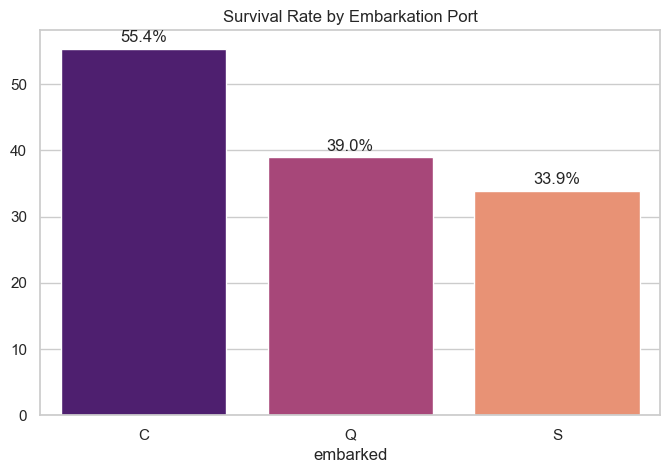

In [13]:
# =========================================
# 6. Embarkation Analysis
# =========================================

plt.figure(figsize=(8, 5))

embark_survival = df.groupby('embarked')['survived'].mean() * 100

sns.barplot(x=embark_survival.index, y=embark_survival.values, palette='magma')

plt.title('Survival Rate by Embarkation Port')

for i, v in enumerate(embark_survival.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.savefig('images/embarkation_survival.png', bbox_inches='tight')
plt.show()

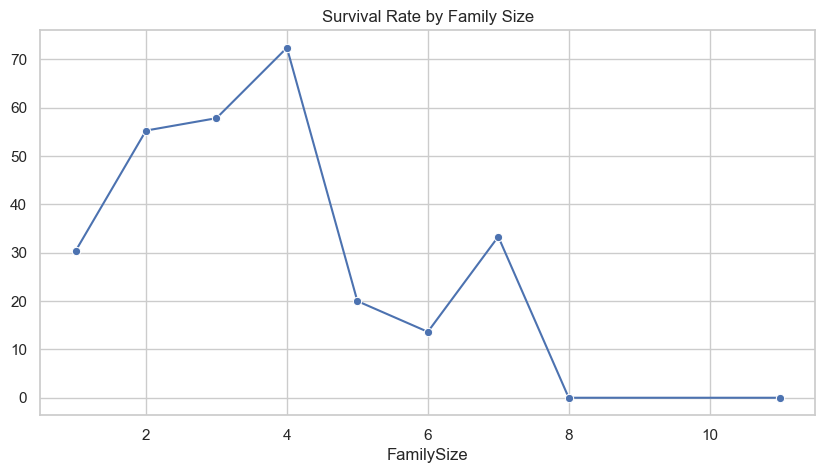

In [14]:
# =========================================
# 7. Family Size Impact
# =========================================

plt.figure(figsize=(10, 5))

family_survival = df.groupby('FamilySize')['survived'].mean() * 100

sns.lineplot(x=family_survival.index, y=family_survival.values, marker='o')

plt.title('Survival Rate by Family Size')
plt.savefig('images/family_size_survival.png', bbox_inches='tight')
plt.show()


===== CORRELATION ANALYSIS =====


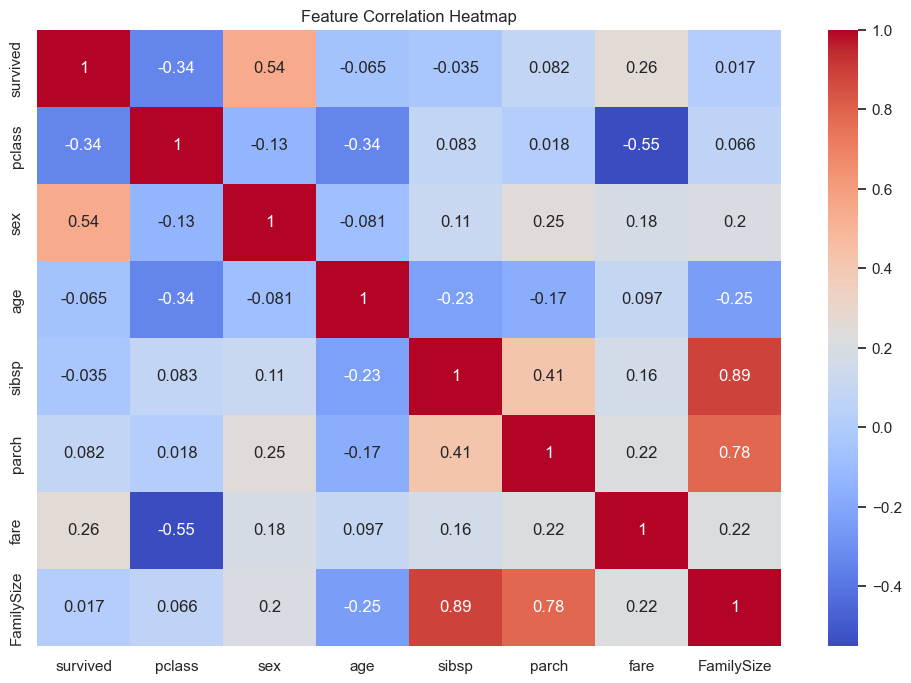

In [15]:
# =========================================
# Correlation Heatmap
# =========================================

print("\n===== CORRELATION ANALYSIS =====")

encoded_df = df.copy()

encoded_df['sex'] = encoded_df['sex'].map({'male': 0, 'female': 1})
encoded_df['embarked'] = encoded_df['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

numeric_cols = ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'FamilySize']

plt.figure(figsize=(12, 8))

sns.heatmap(encoded_df[numeric_cols].corr(), annot=True, cmap='coolwarm')

plt.title('Feature Correlation Heatmap')

plt.savefig('images/correlation_heatmap.png', bbox_inches='tight')
plt.show()

In [16]:
# =========================================
# Insights
# =========================================

print("\n===== BUSINESS INSIGHTS =====")

print("Female Survival Rate:",
      df[df['sex'] == 'female']['survived'].mean() * 100)

print("Male Survival Rate:",
      df[df['sex'] == 'male']['survived'].mean() * 100)

print("\nSurvival by Class:")
print(df.groupby('pclass')['survived'].mean() * 100)

print("\nEDA Completed Successfully!")


===== BUSINESS INSIGHTS =====
Female Survival Rate: 74.20382165605095
Male Survival Rate: 18.890814558058924

Survival by Class:
pclass
1    62.962963
2    47.282609
3    24.236253
Name: survived, dtype: float64

EDA Completed Successfully!
